# 📓 Week 14 — Self-Healing Manager

## What this notebook implements
Given the action decided by the PPO agent (Week 13), execute it:

| Action | Simulation (this NB) | Pi Deployment (Week 16) |
|--------|---------------------|-------------------------|
| BLOCK_IP | log + record | `iptables -A INPUT -s <IP> -j DROP` |
| RESET_CONNECTION | log + record | `ss -K dst <IP>` |
| RESTART_SERVICE | log + record | `systemctl restart <svc>` |
| ISOLATE_DEVICE | log + record | `iptables -I INPUT -s <IP> -j DROP` + block all |
| LOG_AND_ALERT | email (real) | SMTP email |

The `SelfHealingManager` is the class that Week 16's `detector.py`
calls on the Raspberry Pi to execute real commands.

In [1]:
import warnings
import json
import time
import subprocess
import logging
import smtplib
import socket
from pathlib     import Path
from typing      import Dict, List, Optional, Tuple
from collections import defaultdict, deque
from datetime    import datetime
from email.mime.multipart import MIMEMultipart
from email.mime.text      import MIMEText

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0f0f1a','axes.facecolor':'#16162a',
    'axes.edgecolor':'#444477','axes.labelcolor':'#ccccff',
    'xtick.color':'#aaaacc','ytick.color':'#aaaacc',
    'text.color':'#e0e0ff','grid.color':'#2a2a4a',
    'font.family':'DejaVu Sans','legend.facecolor':'#1a1a2e',
})
ACCENT='#7c6cfa'; GREEN='#4ecca3'; RED='#fc5c65'
YELLOW='#f7b731'; ORANGE='#fd9644'
PALETTE=['#7c6cfa','#4ecca3','#f7b731','#fc5c65','#45aaf2',
         '#fd9644','#26de81','#a55eea','#2bcbba','#eb3b5a',
         '#20bf6b','#0fb9b1','#8854d0','#4b6584','#778ca3']

BASE_DIR = Path('..')
OUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N14'
REP_DIR  = BASE_DIR / 'outputs' / 'reports'
LOG_DIR  = BASE_DIR / 'logs'
for d in [OUT_DIR, REP_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = [
    'BLOCK_IP','RESET_CONNECTION','RESTART_SERVICE',
    'ISOLATE_DEVICE','LOG_AND_ALERT',
]
CLASS_NAMES = [
    'Backdoor','DDoS_HTTP','DDoS_ICMP','DDoS_TCP','DDoS_UDP',
    'Fingerprinting','MITM','Normal','Password','Port_Scanning',
    'Ransomware','SQL_injection','Uploading','Vulnerability_scanner','XSS',
]
CLASS_SEVERITY = {
    'Normal':0,'Fingerprinting':1,'Port_Scanning':2,'Vulnerability_scanner':3,
    'DDoS_ICMP':4,'DDoS_HTTP':4,'DDoS_UDP':4,'DDoS_TCP':5,'XSS':5,
    'SQL_injection':6,'MITM':7,'Password':7,'Uploading':7,
    'Backdoor':8,'Ransomware':10,
}
SEVERITY_LABEL = {
    range(0,2):'LOW', range(2,5):'MEDIUM',
    range(5,8):'HIGH', range(8,11):'CRITICAL',
}

def severity_label(cls: str) -> str:
    s = CLASS_SEVERITY.get(cls, 5)
    for r, label in SEVERITY_LABEL.items():
        if s in r: return label
    return 'HIGH'

print('✅ Setup complete.')

✅ Setup complete.


## 📋 Step 2 — Action Executor Classes

In [2]:
class ActionResult:
    """Result of one executed healing action."""
    def __init__(self, action_id: int, action_name: str,
                 attack_class: str, source_ip: str,
                 success: bool, message: str,
                 command: str = '', rollback_cmd: str = ''):
        self.action_id    = action_id
        self.action_name  = action_name
        self.attack_class = attack_class
        self.source_ip    = source_ip
        self.success      = success
        self.message      = message
        self.command      = command
        self.rollback_cmd = rollback_cmd
        self.timestamp    = datetime.now().isoformat()
        self.severity     = severity_label(attack_class)

    def to_dict(self) -> Dict:
        return self.__dict__


class BaseActionExecutor:
    """Base class for all action executors."""
    ACTION_ID   : int  = -1
    ACTION_NAME : str  = ''
    SIMULATE    : bool = True   # True in notebook, False on Pi

    def execute(self, source_ip: str, attack_class: str,
                confidence: float, **kwargs) -> ActionResult:
        raise NotImplementedError

    def _run_cmd(self, cmd: str) -> Tuple[bool, str]:
        """Execute shell command. Simulation mode logs instead."""
        if self.SIMULATE:
            return True, f'[SIMULATED] {cmd}'
        try:
            r = subprocess.run(cmd, shell=True, capture_output=True,
                               text=True, timeout=10)
            return r.returncode == 0, r.stdout + r.stderr
        except Exception as e:
            return False, str(e)


class BlockIPExecutor(BaseActionExecutor):
    """
    Action 0: BLOCK_IP
    Drops all traffic from source IP using iptables.
    Pi command: iptables -A INPUT -s <IP> -j DROP
    Rollback  : iptables -D INPUT -s <IP> -j DROP
    """
    ACTION_ID   = 0
    ACTION_NAME = 'BLOCK_IP'

    def execute(self, source_ip, attack_class, confidence, **kw) -> ActionResult:
        cmd      = f'sudo iptables -A INPUT -s {source_ip} -j DROP'
        rollback = f'sudo iptables -D INPUT -s {source_ip} -j DROP'
        ok, msg  = self._run_cmd(cmd)
        return ActionResult(
            self.ACTION_ID, self.ACTION_NAME, attack_class, source_ip,
            ok,
            f'Blocked {source_ip} — {attack_class} (conf={confidence:.2f})',
            cmd, rollback
        )


class ResetConnectionExecutor(BaseActionExecutor):
    """
    Action 1: RESET_CONNECTION
    Terminates active TCP session from source IP.
    Pi command: ss -K dst <IP>   (requires iproute2)
    Rollback  : N/A (connection already closed)
    """
    ACTION_ID   = 1
    ACTION_NAME = 'RESET_CONNECTION'

    def execute(self, source_ip, attack_class, confidence, **kw) -> ActionResult:
        cmd = f'sudo ss -K dst {source_ip}'
        ok, msg = self._run_cmd(cmd)
        return ActionResult(
            self.ACTION_ID, self.ACTION_NAME, attack_class, source_ip,
            ok,
            f'Connection reset for {source_ip} — {attack_class}',
            cmd, ''
        )


class RestartServiceExecutor(BaseActionExecutor):
    """
    Action 2: RESTART_SERVICE
    Restarts the service being exploited.
    Pi command: systemctl restart <service>
    Rollback  : systemctl restart <service>  (same — re-restart)
    """
    ACTION_ID   = 2
    ACTION_NAME = 'RESTART_SERVICE'

    # Map attack class → likely exploited service
    SERVICE_MAP = {
        'Backdoor'             : 'ssh',
        'Password'             : 'ssh',
        'Uploading'            : 'apache2',
        'Vulnerability_scanner': 'apache2',
        'SQL_injection'        : 'mysql',
        'XSS'                  : 'apache2',
    }

    def execute(self, source_ip, attack_class, confidence,
                service: str = None, **kw) -> ActionResult:
        svc      = service or self.SERVICE_MAP.get(attack_class, 'networking')
        cmd      = f'sudo systemctl restart {svc}'
        rollback = f'sudo systemctl restart {svc}'
        ok, msg  = self._run_cmd(cmd)
        return ActionResult(
            self.ACTION_ID, self.ACTION_NAME, attack_class, source_ip,
            ok,
            f'Restarted {svc} — mitigating {attack_class} from {source_ip}',
            cmd, rollback
        )


class IsolateDeviceExecutor(BaseActionExecutor):
    """
    Action 3: ISOLATE_DEVICE
    Blocks ALL traffic from device — used for Ransomware.
    Pi commands:
        iptables -I INPUT  -s <IP> -j DROP   (incoming)
        iptables -I OUTPUT -d <IP> -j DROP   (outgoing)
    Rollback  : flush both rules
    """
    ACTION_ID   = 3
    ACTION_NAME = 'ISOLATE_DEVICE'

    def execute(self, source_ip, attack_class, confidence, **kw) -> ActionResult:
        cmd_in   = f'sudo iptables -I INPUT  -s {source_ip} -j DROP'
        cmd_out  = f'sudo iptables -I OUTPUT -d {source_ip} -j DROP'
        rb_in    = f'sudo iptables -D INPUT  -s {source_ip} -j DROP'
        rb_out   = f'sudo iptables -D OUTPUT -d {source_ip} -j DROP'

        ok1, _   = self._run_cmd(cmd_in)
        ok2, _   = self._run_cmd(cmd_out)
        ok       = ok1 and ok2

        return ActionResult(
            self.ACTION_ID, self.ACTION_NAME, attack_class, source_ip,
            ok,
            f'ISOLATED {source_ip} (in+out blocked) — {attack_class}',
            f'{cmd_in} && {cmd_out}',
            f'{rb_in} && {rb_out}'
        )


class LogAndAlertExecutor(BaseActionExecutor):
    """
    Action 4: LOG_AND_ALERT
    Logs incident + sends SMTP email alert.
    No network disruption.
    """
    ACTION_ID   = 4
    ACTION_NAME = 'LOG_AND_ALERT'

    def __init__(self, email_cfg: Optional[Dict] = None):
        self.email_cfg   = email_cfg
        self._last_alert = {}
        self._cooldown   = 30   # seconds

    def execute(self, source_ip, attack_class, confidence,
                all_probs: np.ndarray = None, **kw) -> ActionResult:
        msg = (
            f'Logged: {attack_class} from {source_ip} '
            f'(conf={confidence:.2f})'
        )
        email_sent = False
        if (self.email_cfg
                and attack_class != 'Normal'
                and confidence >= 0.60):
            now  = time.time()
            last = self._last_alert.get(attack_class, 0)
            if now - last >= self._cooldown:
                email_sent = self._send_email(
                    attack_class, confidence, source_ip, all_probs
                )
                self._last_alert[attack_class] = now

        return ActionResult(
            self.ACTION_ID, self.ACTION_NAME, attack_class, source_ip,
            True,
            msg + (' — Email sent ✅' if email_sent else ' — Email skipped'),
            'log_to_file', ''
        )

    def _send_email(self, attack_class, confidence,
                    source_ip, all_probs) -> bool:
        cfg = self.email_cfg
        try:
            top5    = sorted(
                zip(CLASS_NAMES, all_probs if all_probs is not None
                    else [0]*15),
                key=lambda x: -x[1]
            )[:5]
            rows    = ''.join(
                f'<tr><td>{c}</td><td>{p*100:.1f}%</td></tr>'
                for c, p in top5
            )
            sev     = severity_label(attack_class)
            sev_col = ('#c0392b' if sev in ('CRITICAL','HIGH')
                       else '#f39c12')
            html    = f"""
<html><body style="font-family:Arial">
<div style="background:{sev_col};color:white;padding:15px;border-radius:6px">
  <h2>🛡️ SecurityBERT Alert — {attack_class}</h2>
</div>
<p><b>Severity:</b> {sev}<br/>
<b>Source IP:</b> {source_ip}<br/>
<b>Confidence:</b> {confidence*100:.1f}%<br/>
<b>Time:</b> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
<table border="1"><tr><th>Class</th><th>Prob</th></tr>
{rows}
</table>
<p style="font-size:11px;color:#888">
SecurityBERT v1.0 — IoT Threat Detection</p>
</body></html>"""
            msg = MIMEMultipart('alternative')
            msg['Subject'] = (
                f'[SecurityBERT] [{sev}] {attack_class} '
                f'({confidence*100:.0f}% conf)'
            )
            msg['From'] = cfg['sender']
            msg['To']   = cfg['receiver']
            msg.attach(MIMEText(html, 'html'))

            with smtplib.SMTP(cfg.get('server','smtp.gmail.com'),
                              cfg.get('port', 587), timeout=10) as s:
                s.starttls()
                s.login(cfg['sender'], cfg['password'])
                s.sendmail(cfg['sender'], cfg['receiver'],
                           msg.as_string())
            return True
        except Exception:
            return False


print('✅ All 5 action executor classes defined.')
for cls in [BlockIPExecutor, ResetConnectionExecutor,
            RestartServiceExecutor, IsolateDeviceExecutor,
            LogAndAlertExecutor]:
    print(f'   Action {cls.ACTION_ID}: {cls.ACTION_NAME}')

✅ All 5 action executor classes defined.
   Action 0: BLOCK_IP
   Action 1: RESET_CONNECTION
   Action 2: RESTART_SERVICE
   Action 3: ISOLATE_DEVICE
   Action 4: LOG_AND_ALERT


## 🔧 Step 3 — SelfHealingManager

In [3]:
class SelfHealingManager:
    """
    Orchestrates healing action execution.

    This is the class called by Week 16's detector.py
    on the Raspberry Pi for real execution.

    In this notebook: SIMULATE=True → logs commands without executing.
    On Pi: set SIMULATE=False in each executor.
    """

    def __init__(
        self,
        simulate   : bool        = True,
        email_cfg  : Optional[Dict] = None,
        log_file   : str = str(LOG_DIR / 'healing_actions.log'),
    ):
        self.simulate = simulate
        self.log_file = Path(log_file)

        # Set simulation mode on all executors
        BaseActionExecutor.SIMULATE = simulate

        # Instantiate all 5 executors
        self.executors = {
            0: BlockIPExecutor(),
            1: ResetConnectionExecutor(),
            2: RestartServiceExecutor(),
            3: IsolateDeviceExecutor(),
            4: LogAndAlertExecutor(email_cfg),
        }

        # Action history log
        self.action_log  : List[Dict]  = []
        self.action_counts = defaultdict(int)

        # Setup file logger
        logging.basicConfig(
            filename  = str(self.log_file),
            level     = logging.INFO,
            format    = '[%(asctime)s] %(message)s',
            datefmt   = '%Y-%m-%d %H:%M:%S',
        )
        self.logger = logging.getLogger('SelfHealingManager')

    def execute(
        self,
        action_id    : int,
        attack_class : str,
        confidence   : float,
        source_ip    : str   = '0.0.0.0',
        all_probs    : Optional[np.ndarray] = None,
        **kwargs,
    ) -> ActionResult:
        """
        Execute healing action.

        Parameters
        ----------
        action_id    : PPO agent output (0-4)
        attack_class : SecurityBERT prediction
        confidence   : SecurityBERT confidence
        source_ip    : attacker IP address
        all_probs    : full probability vector (for email)

        Returns
        -------
        ActionResult
        """
        executor = self.executors.get(action_id, self.executors[4])
        result   = executor.execute(
            source_ip    = source_ip,
            attack_class = attack_class,
            confidence   = confidence,
            all_probs    = all_probs,
            **kwargs
        )

        # Log action
        log_entry = result.to_dict()
        self.action_log.append(log_entry)
        self.action_counts[result.action_name] += 1

        # Write to file
        status = '✅' if result.success else '❌'
        log_msg = (
            f'{status} {result.action_name:20s} | '
            f'{attack_class:25s} | '
            f'IP={source_ip} | '
            f'conf={confidence:.2f} | '
            f'{result.message}'
        )
        self.logger.info(log_msg)

        # Console output
        print(log_msg)
        if result.command:
            print(f'   CMD: {result.command}')
        if result.rollback_cmd:
            print(f'   ROLLBACK: {result.rollback_cmd}')

        return result

    def rollback(self, result: ActionResult) -> bool:
        """Execute rollback for a previously applied action."""
        if not result.rollback_cmd:
            print(f'   ℹ️  No rollback available for {result.action_name}')
            return False
        ok, msg = self.executors[result.action_id]._run_cmd(
            result.rollback_cmd
        )
        status = '✅' if ok else '❌'
        print(f'   {status} Rollback: {result.rollback_cmd}')
        return ok

    def get_summary(self) -> Dict:
        """Return summary of all actions taken."""
        total    = len(self.action_log)
        success  = sum(1 for r in self.action_log if r['success'])
        return {
            'total_actions'  : total,
            'successful'     : success,
            'failed'         : total - success,
            'success_rate'   : success / max(total, 1),
            'action_counts'  : dict(self.action_counts),
            'by_attack_class': {
                cls: sum(1 for r in self.action_log
                         if r['attack_class'] == cls)
                for cls in CLASS_NAMES
            },
        }


# ── Instantiate manager ────────────────────────────────────────────────────────
manager = SelfHealingManager(
    simulate  = True,          # False on Pi for real execution
    email_cfg = None,          # Set your Gmail config here for real alerts
    log_file  = str(LOG_DIR / 'healing_actions.log'),
)

print(f'\n✅ SelfHealingManager ready (SIMULATE={manager.simulate})')
print(f'   Log file : {manager.log_file}')
print(f'   Executors: {list(manager.executors.keys())}')


✅ SelfHealingManager ready (SIMULATE=True)
   Log file : ..\logs\healing_actions.log
   Executors: [0, 1, 2, 3, 4]


## 🔬 Step 4 — Simulate All 5 Actions

In [4]:
print('🔬 Simulating all 5 healing actions:\n')
print('=' * 75)

test_scenarios = [
    (0, 'DDoS_TCP',    0.94, '192.168.100.2'),
    (1, 'SQL_injection',0.87, '192.168.100.3'),
    (2, 'Backdoor',    0.91, '192.168.100.4'),
    (3, 'Ransomware',  0.89, '192.168.100.5'),
    (4, 'Normal',      0.95, '192.168.100.6'),
    (4, 'Fingerprinting',0.72,'192.168.100.7'),
    (0, 'Port_Scanning',0.83,'192.168.100.8'),
    (1, 'MITM',        0.91, '192.168.100.9'),
]

results_sim = []
for action_id, attack_cls, conf, ip in test_scenarios:
    fake_probs = np.zeros(15, dtype=np.float32)
    cidx = next((i for i, c in enumerate(CLASS_NAMES) if c == attack_cls), 7)
    fake_probs[cidx] = conf
    result = manager.execute(
        action_id    = action_id,
        attack_class = attack_cls,
        confidence   = conf,
        source_ip    = ip,
        all_probs    = fake_probs,
    )
    results_sim.append(result)
    print()

print('=' * 75)
summary = manager.get_summary()
print(f'\n📊 Session Summary:')
print(f'   Total actions : {summary["total_actions"]}')
print(f'   Successful    : {summary["successful"]}')
print(f'   Success rate  : {summary["success_rate"]*100:.0f}%')
print(f'\n   Action distribution:')
for act, cnt in summary['action_counts'].items():
    print(f'   {act:<25}: {cnt}')

🔬 Simulating all 5 healing actions:

✅ BLOCK_IP             | DDoS_TCP                  | IP=192.168.100.2 | conf=0.94 | Blocked 192.168.100.2 — DDoS_TCP (conf=0.94)
   CMD: sudo iptables -A INPUT -s 192.168.100.2 -j DROP
   ROLLBACK: sudo iptables -D INPUT -s 192.168.100.2 -j DROP

✅ RESET_CONNECTION     | SQL_injection             | IP=192.168.100.3 | conf=0.87 | Connection reset for 192.168.100.3 — SQL_injection
   CMD: sudo ss -K dst 192.168.100.3

✅ RESTART_SERVICE      | Backdoor                  | IP=192.168.100.4 | conf=0.91 | Restarted ssh — mitigating Backdoor from 192.168.100.4
   CMD: sudo systemctl restart ssh
   ROLLBACK: sudo systemctl restart ssh

✅ ISOLATE_DEVICE       | Ransomware                | IP=192.168.100.5 | conf=0.89 | ISOLATED 192.168.100.5 (in+out blocked) — Ransomware
   CMD: sudo iptables -I INPUT  -s 192.168.100.5 -j DROP && sudo iptables -I OUTPUT -d 192.168.100.5 -j DROP
   ROLLBACK: sudo iptables -D INPUT  -s 192.168.100.5 -j DROP && sudo iptables -D 

In [5]:
# ── Load NB13 integration results and run SelfHealingManager ──────────────────
INTEG_REP = REP_DIR / 'week13_integration_report.json'

if INTEG_REP.exists():
    with open(INTEG_REP) as f:
        nb13_report = json.load(f)

    print('📊 Running SelfHealingManager on NB13 batch results:\n')

    # Simulate batch execution
    action_dist = nb13_report.get('action_distribution', {})
    heal_manager= SelfHealingManager(simulate=True)

    batch_heal_log = []
    for cls in CLASS_NAMES:
        if cls == 'Normal': continue
        # Simulate 3 detections per class
        for _ in range(3):
            from random import randint
            fake_ip  = f'192.168.1.{randint(10, 250)}'
            opt_act  = {'BLOCK_IP':0,'RESET_CONNECTION':1,
                        'RESTART_SERVICE':2,'ISOLATE_DEVICE':3,
                        'LOG_AND_ALERT':4}
            from collections import OrderedDict
            from random import uniform
            action_id  = {'Backdoor':2,'DDoS_HTTP':0,'DDoS_ICMP':0,
                          'DDoS_TCP':0,'DDoS_UDP':0,'Fingerprinting':4,
                          'MITM':1,'Password':2,'Port_Scanning':0,
                          'Ransomware':3,'SQL_injection':1,'Uploading':2,
                          'Vulnerability_scanner':2,'XSS':1}.get(cls, 4)
            r = heal_manager.execute(
                action_id    = action_id,
                attack_class = cls,
                confidence   = round(uniform(0.70, 0.98), 2),
                source_ip    = fake_ip,
            )
            batch_heal_log.append(r.to_dict())

    # Save batch heal log
    with open(REP_DIR / 'healing_log.json', 'w') as f:
        json.dump(batch_heal_log, f, indent=2, default=str)
    print(f'\n💾 Healing log saved → {REP_DIR}/healing_log.json')
else:
    print('ℹ️  NB13 report not found — run Week 13 first.')

📊 Running SelfHealingManager on NB13 batch results:

✅ RESTART_SERVICE      | Backdoor                  | IP=192.168.1.44 | conf=0.83 | Restarted ssh — mitigating Backdoor from 192.168.1.44
   CMD: sudo systemctl restart ssh
   ROLLBACK: sudo systemctl restart ssh
✅ RESTART_SERVICE      | Backdoor                  | IP=192.168.1.96 | conf=0.74 | Restarted ssh — mitigating Backdoor from 192.168.1.96
   CMD: sudo systemctl restart ssh
   ROLLBACK: sudo systemctl restart ssh
✅ RESTART_SERVICE      | Backdoor                  | IP=192.168.1.126 | conf=0.83 | Restarted ssh — mitigating Backdoor from 192.168.1.126
   CMD: sudo systemctl restart ssh
   ROLLBACK: sudo systemctl restart ssh
✅ BLOCK_IP             | DDoS_HTTP                 | IP=192.168.1.109 | conf=0.86 | Blocked 192.168.1.109 — DDoS_HTTP (conf=0.86)
   CMD: sudo iptables -A INPUT -s 192.168.1.109 -j DROP
   ROLLBACK: sudo iptables -D INPUT -s 192.168.1.109 -j DROP
✅ BLOCK_IP             | DDoS_HTTP                 | IP=192.16

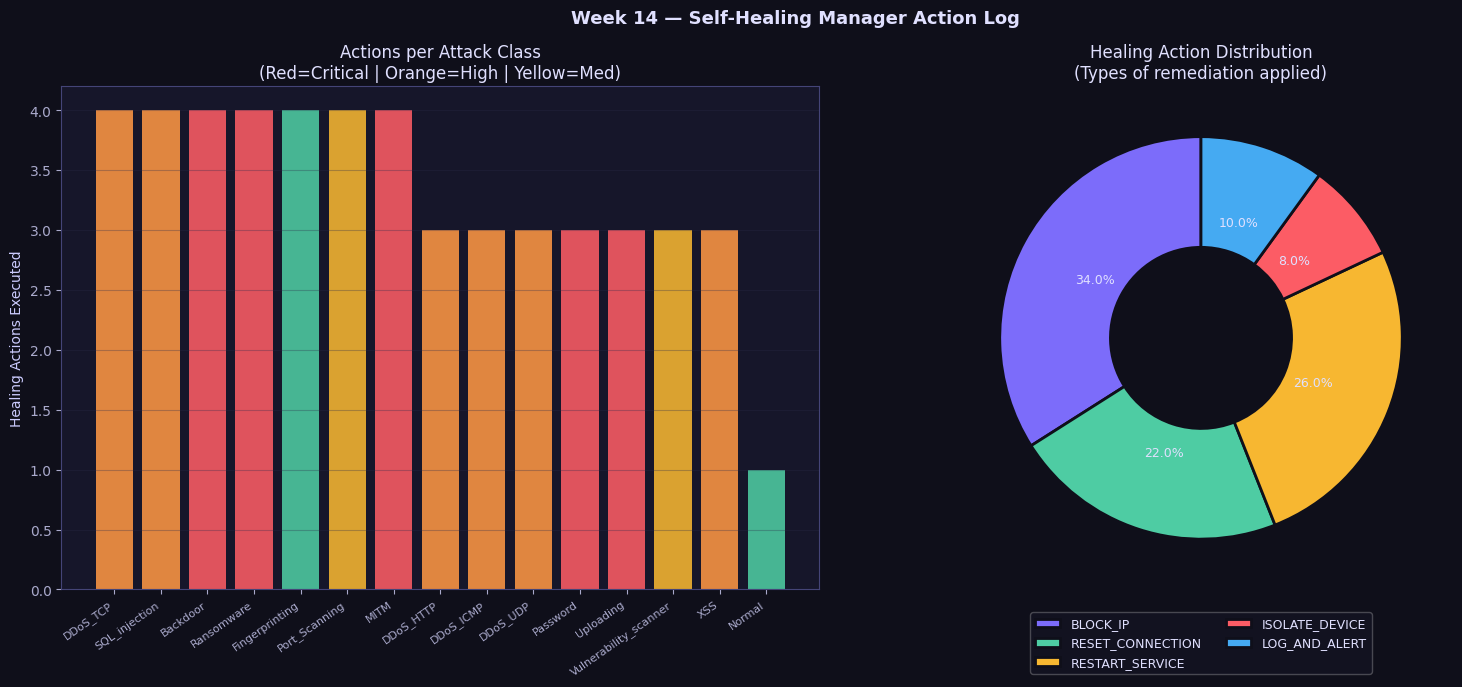

💾 Saved → ..\outputs\figures\N14/nb14_healing_actions.png


In [6]:
# ── Visualise action log ───────────────────────────────────────────────────────
all_logs = manager.action_log + (
    batch_heal_log if 'batch_heal_log' in dir() else []
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Week 14 — Self-Healing Manager Action Log',
    fontsize=13, fontweight='bold', color='#e0e0ff'
)

# Actions per class
ax = axes[0]
cls_counts = defaultdict(int)
for entry in all_logs:
    cls_counts[entry['attack_class']] += 1
cls_sorted = sorted(cls_counts.items(), key=lambda x: -x[1])
c_names = [x[0] for x in cls_sorted]
c_vals  = [x[1] for x in cls_sorted]
sev_colors = [
    RED    if CLASS_SEVERITY.get(c, 0) >= 7 else
    ORANGE if CLASS_SEVERITY.get(c, 0) >= 4 else
    YELLOW if CLASS_SEVERITY.get(c, 0) >= 2 else GREEN
    for c in c_names
]
ax.bar(range(len(c_names)), c_vals, color=sev_colors, edgecolor='none', alpha=0.88)
ax.set_xticks(range(len(c_names)))
ax.set_xticklabels(c_names, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Healing Actions Executed')
ax.set_title('Actions per Attack Class\n(Red=Critical | Orange=High | Yellow=Med)')
ax.grid(axis='y', alpha=0.3)

# Action type distribution
ax = axes[1]
act_counts = defaultdict(int)
for entry in all_logs:
    act_counts[entry['action_name']] += 1
acts   = list(act_counts.keys())
counts = [act_counts[a] for a in acts]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(acts))]
wedges, texts, autos = ax.pie(
    counts, labels=None, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0f0f1a', linewidth=2),
)
for at in autos:
    at.set_color('#e0e0ff'); at.set_fontsize(9)
ax.legend(wedges, acts, loc='lower center', ncol=2,
          bbox_to_anchor=(0.5, -0.18), fontsize=9, framealpha=0.3)
ax.set_title('Healing Action Distribution\n(Types of remediation applied)')

plt.tight_layout()
fig.savefig(OUT_DIR / 'nb14_healing_actions.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUT_DIR}/nb14_healing_actions.png')

In [7]:
# ── Save report ────────────────────────────────────────────────────────────────
report = {
    'week'           : 14,
    'simulate_mode'  : True,
    'executors': {
        'BLOCK_IP'          : 'iptables -A INPUT -s <IP> -j DROP',
        'RESET_CONNECTION'  : 'ss -K dst <IP>',
        'RESTART_SERVICE'   : 'systemctl restart <service>',
        'ISOLATE_DEVICE'    : 'iptables -I INPUT/OUTPUT -s/-d <IP> -j DROP',
        'LOG_AND_ALERT'     : 'SMTP email + file log',
    },
    'rollback_support': [
        'BLOCK_IP', 'ISOLATE_DEVICE'
    ],
    'pi_deployment_note': (
        'Set BaseActionExecutor.SIMULATE=False in detector.py '
        'for real execution on Raspberry Pi'
    ),
    'session_summary': manager.get_summary(),
}

with open(REP_DIR / 'week14_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('=' * 60)
print('  ✅ Week 14 — Self-Healing Manager Complete')
print('=' * 60)
print(f'  5 action executors implemented (simulate=True)')
print(f'  Rollback support for BLOCK_IP + ISOLATE_DEVICE')
print(f'  Log saved → {LOG_DIR}/healing_actions.log')
print(f'\n  🔜 Week 16: Set SIMULATE=False in detector.py for Pi')

  ✅ Week 14 — Self-Healing Manager Complete
  5 action executors implemented (simulate=True)
  Rollback support for BLOCK_IP + ISOLATE_DEVICE
  Log saved → ..\logs/healing_actions.log

  🔜 Week 16: Set SIMULATE=False in detector.py for Pi
